

# **Fashion MNIST dataset with Neural Network classification**





## Import libraries and dataset

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import regularizers, optimizers
import math

import seaborn as sns

In [2]:
(train_data, train_labels) , (test_data, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
## dimensions of X and y
print(f"Shape of X_train: {train_data.shape}")
print(f"Shape of y_train: {train_labels.shape}")
print(f"Shape of X_test: {test_data.shape}")
print(f"Shape of y_test: {test_labels.shape}")

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


## Lets visualize some data

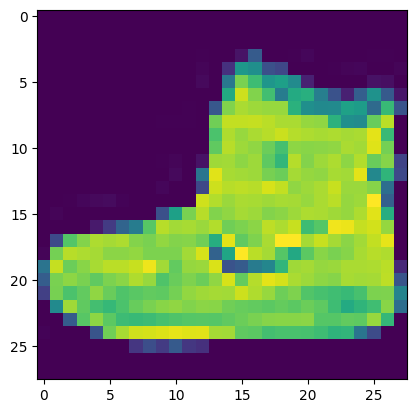

In [4]:
plt.imshow(train_data[0]);

In [5]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [6]:
#perform label mapping
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

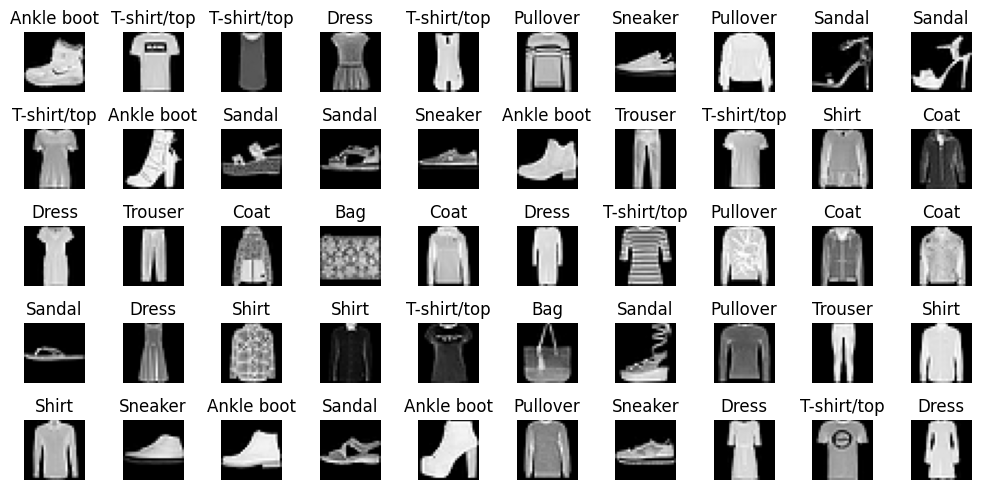

In [7]:
# lets try to visualize random train data and lables

plt.figure(figsize=(10,5))
for k in range(50):
    plt.subplot(5,10,k+1)
    plt.imshow(train_data[k],cmap='gray')
    plt.axis('off')
    plt.title(f"{class_names[train_labels[k]]}")

plt.tight_layout()

## Data Preprocessing and Normalize the input


In [8]:
# Reshape the data
X_train = train_data
X_test = test_data
y_train  = train_labels
y_test = test_labels

In [9]:
# check the shape
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [10]:
## Normalize the data between 0 and 1
print(f"X_train_min: {X_train.min()}, X_train_max: {X_train.max()}")
X_train = X_train / 255.0
X_test = X_test / 255.0
print(f"X_train_min: {X_train.min()}, X_train_max: {X_train.max()}")

X_train_min: 0, X_train_max: 255
X_train_min: 0.0, X_train_max: 1.0


## Create , compile and fit model

In [11]:
def train_test_loop(iterations, lr, Lambda, verbose=True):

  #Hyperparameters
  iterations = iterations
  learning_rate = lr
  hidden_nodes = 256
  output_nodes = 10

  # Create the model
  fashion_model = tf.keras.Sequential([
      tf.keras.layers.Flatten(input_shape=(28,28)),
      tf.keras.layers.Dense(hidden_nodes, activation='relu'),
      tf.keras.layers.Dense(hidden_nodes, activation='relu'),
      tf.keras.layers.Dense(output_nodes, activation='softmax',kernel_regularizer=regularizers.l2(Lambda))
  ])


  sgd = optimizers.SGD(learning_rate=learning_rate, decay=1e-6, momentum=0.9)

  #compile Model
  fashion_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=sgd, metrics=['accuracy'])

  #fit_model
  fashion_model_history  = fashion_model.fit(X_train, y_train, epochs=iterations, batch_size=1000, verbose=0, validation_data=(X_test, y_test))

  #evaluate model
  score = fashion_model.evaluate(X_test, y_test, verbose=1)
  return fashion_model, fashion_model_history, score

### Hyperparameter Optimization

In [12]:
for k in range(1,6):
  lr = math.pow(10, np.random.uniform(-4.0, -1.0))
  Lambda = math.pow(10, np.random.uniform(-4, -2))
  best_acc_score = train_test_loop(50, lr, Lambda, verbose=False)
  print(f"Try {k}/5: lr: {lr}, Lambda: {Lambda}, accuracy: {best_acc_score}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7872 - loss: 0.7938
Try 1/5: lr: 0.00029984427692110997, Lambda: 0.008809406425444635, accuracy: (<Sequential name=sequential, built=True>, <keras.src.callbacks.history.History object at 0x7cb58d3f6ba0>, [0.7938463091850281, 0.7871999740600586])
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8883 - loss: 0.3404
Try 2/5: lr: 0.0960395327035418, Lambda: 0.0011821347819746177, accuracy: (<Sequential name=sequential_1, built=True>, <keras.src.callbacks.history.History object at 0x7cb5871a5590>, [0.34035423398017883, 0.8883000016212463])
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7739 - loss: 0.7069
Try 3/5: lr: 0.0002179676046639076, Lambda: 0.0015588600624492591, accuracy: (<Sequential name=sequential_2, built=True>, <keras.src.callbacks.history.History object at 0x7cb584284550>, [0.7068625688552856, 0.7738999724388123])
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8270 - loss: 0.5832
Try 4/5: lr: 0.00087

In [13]:
lr = 0.0969
Lambda = 0.000911 # values taken from above
fashion_model, fashion_model_history, score = train_test_loop(50, lr, Lambda)
fashion_model

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8862 - loss: 0.3611


<Sequential name=sequential_5, built=True>

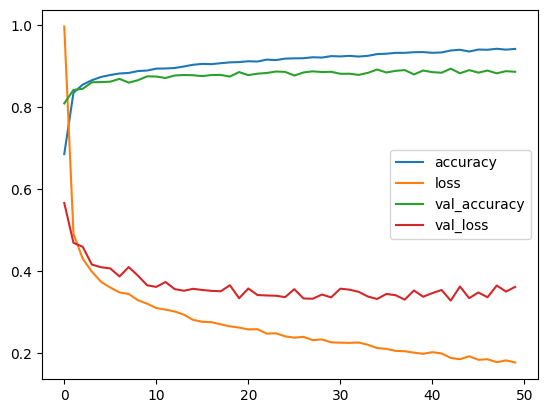

In [14]:
pd.DataFrame(fashion_model_history.history).plot();

In [15]:
loss, accuracy = fashion_model.evaluate(X_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {100*accuracy:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8862 - loss: 0.3611
Model loss on the test set: 0.3611328899860382
Model accuracy on the test set: 88.62%


In [16]:
y_pred = fashion_model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## **Plot Confusion Matrix**

In [17]:
def plot_fashion_metrics(which_data, y_true, y_pred, class_names=class_names):
    """Plots both a 10x10 Confusion Matrix and a Classification Report

    Heatmap for multi-class targets like Fashion MNIST.
    """
    print(f"--- Metrics for {which_data} Data ---\n")

    # If y_pred contains probabilities/logits (e.g., shape (N, 10)), convert to class indices
    if y_pred.ndim > 1:
        y_pred = y_pred.argmax(axis=1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

    sns.heatmap(
        df_cm,
        ax=ax1,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
    )
    ax1.set_title("Confusion Matrix", fontsize=14)
    ax1.set_xlabel("Predicted Label", fontsize=12)
    ax1.set_ylabel("True Label", fontsize=12)
    ax1.tick_params(axis="x", rotation=45)

    # --- 2. Classification Metrics (Precision, Recall, F1) ---
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )

    # Extract metrics, dropping 'support' and converting to DataFrame
    df_report = pd.DataFrame(report_dict).iloc[:-1, :].T

    sns.heatmap(
        df_report,
        ax=ax2,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar=True,
        linewidths=0.5,
    )
    ax2.set_title("Classification Metrics Heatmap", fontsize=14)

    plt.tight_layout()
    plt.show()

--- Metrics for Test Data Data ---



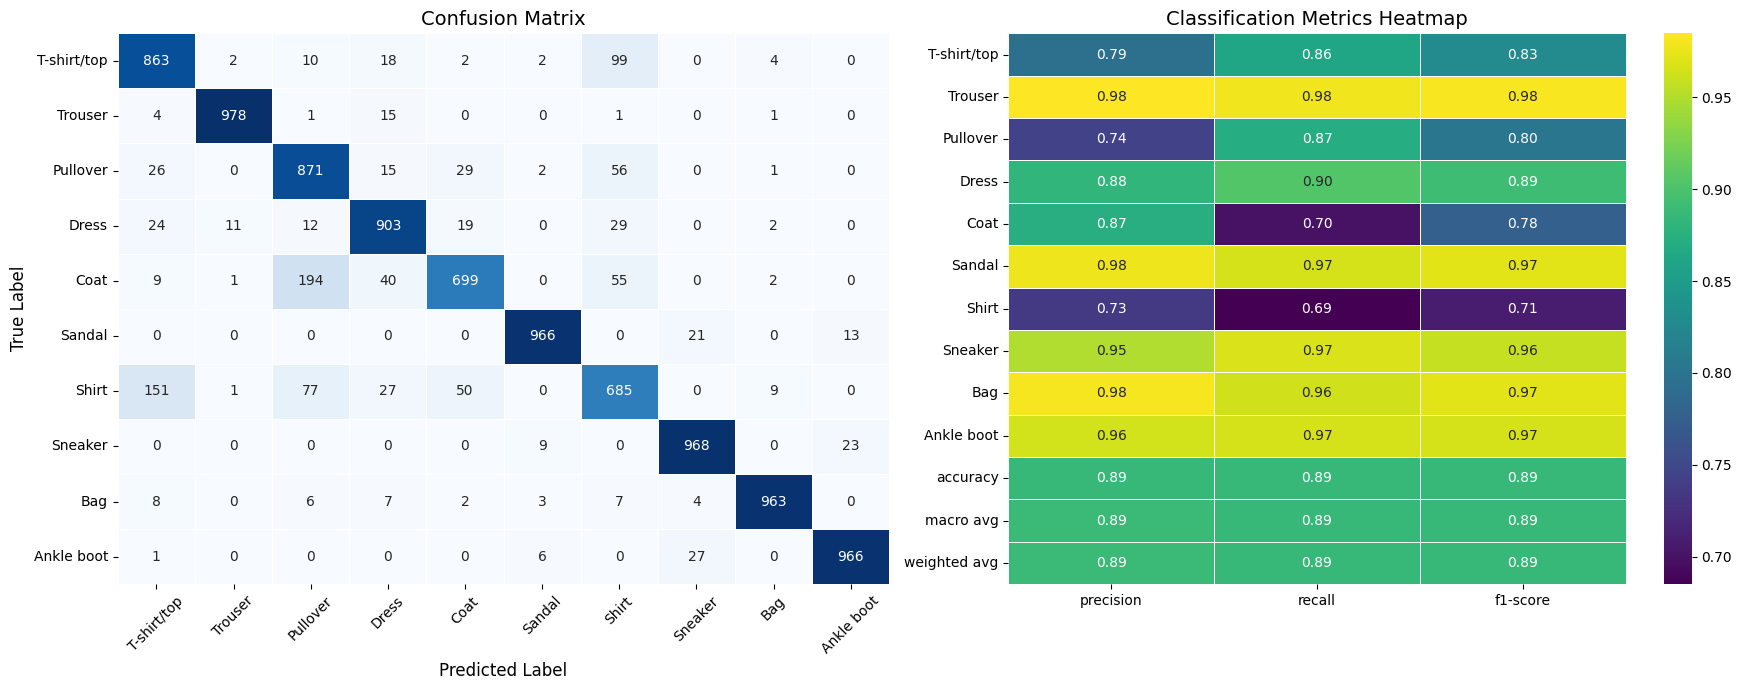

In [18]:
plot_fashion_metrics(which_data='Test Data', y_true=y_test, y_pred=y_pred, class_names=class_names)

**Predict data on test set**

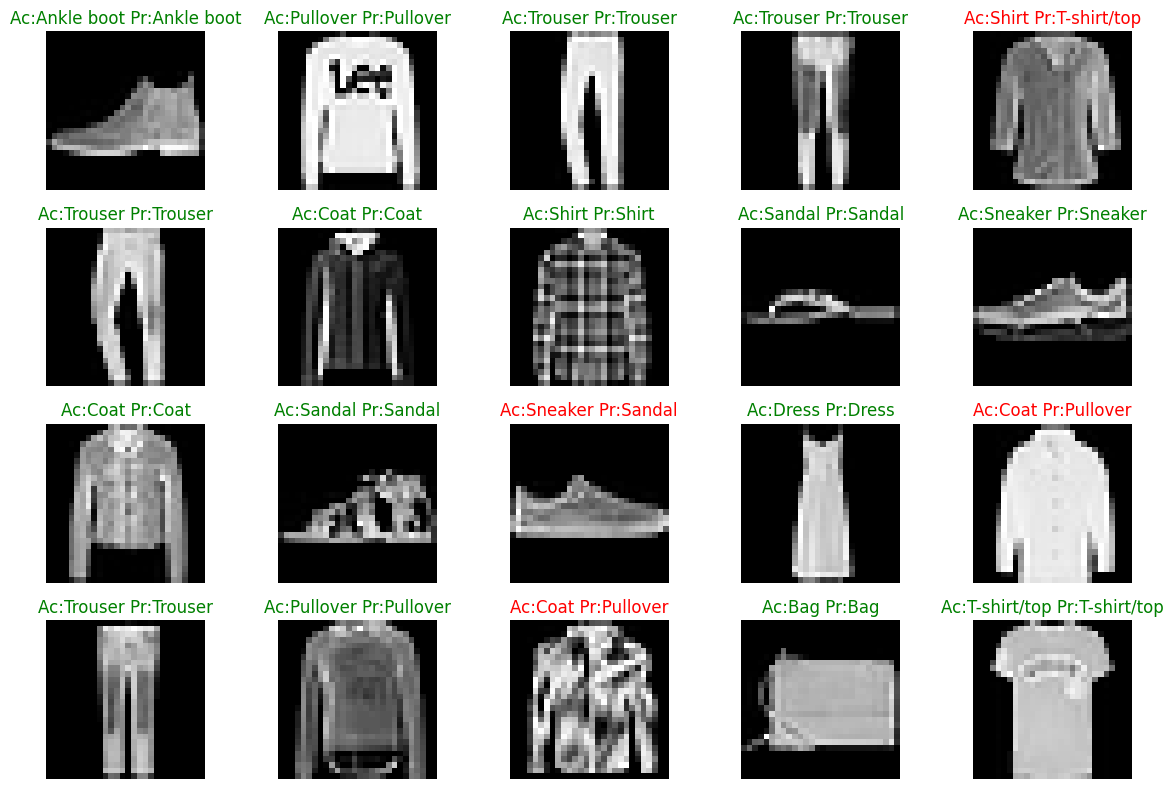

In [19]:
## Lets try to predict on few test data


plt.figure(figsize=(12,8))
for k in range(20):
    plt.subplot(4,5,k+1)
    plt.imshow(X_test[k].reshape(28,28),cmap='gray')
    plt.axis('off')
    pred = fashion_model.predict(X_test[k].reshape(1,28,28), verbose=0)

    if y_test[k] == np.argmax(pred):
      plt.title(f"Ac:{class_names[y_test[k]]} Pr:{class_names[np.argmax(pred)]}", color='green')
    else:
      plt.title(f"Ac:{class_names[y_test[k]]} Pr:{class_names[np.argmax(pred)]}", color='red')

plt.tight_layout()